In [33]:
from auxiliary_functions import (
    fetch_profile, load_price_from_csv, load_technology_parameters, BETA_OBJ_DEFAULT)
from shipp.timeseries import TimeSeries
from shipp.components import Production, Storage
import math
import matplotlib.pyplot as plt
import numpy as np
from shipp.kernel_pyomo import solve_lp_pyomo_sizing
import time
import warnings
import numpy_financial as npf

# Case parameters
TOKEN = '96e53647b34ef4fb37b6958e9285eff9938ad7ce'
LAT, LON = 52.52, 4.90
DATE_FROM, DATE_TO = '2023-01-01', '2024-01-01'
COUNTRY = 'DNK'          # placeholder, using Danish parameters
PARAM_YEAR = 2025        
N = 24 * 365                  
DT = 1.0
N_YEAR = 25
DISCOUNT_RATE = 0.03
P_GRID_MAX = 150            # in MW 
BETA_OBJ = BETA_OBJ_DEFAULT   # 1e-4

TECH_CSV = 'technology_parameters.csv'
PRICE_CSV = 'ember_prices.csv'

In [34]:
BUDGET = 300e6
BUDGET_TOL = 1e-3
I_MAX = BUDGET * (1 + BUDGET_TOL)
I_MIN = BUDGET * (1 - BUDGET_TOL)
# I_MAX = None
# I_MIN = None

In [35]:
# Per-unit profiles
wind_ts = fetch_profile('wind', LAT, LON, DATE_FROM, DATE_TO, TOKEN,
                        height=90, turbine='Vestas V150 4500')
pv_ts = fetch_profile('pv', LAT, LON, DATE_FROM, DATE_TO, TOKEN,
                      tilt=35, azim=180)
price_ts = load_price_from_csv('NLD', 2023, PRICE_CSV)

# Slice to the case horizon
wind_ts = type(wind_ts)(wind_ts.data[:N], DT)
pv_ts = type(pv_ts)(pv_ts.data[:N], DT)
price_ts = type(price_ts)(price_ts.data[:N], DT)

# Technology parameters
params = load_technology_parameters(TECH_CSV, COUNTRY, PARAM_YEAR)

In [36]:
# Pre-annualization: CAPEX is multiplied by n_year / lifetime so the
# kernel sees the project-horizon cost
wind_life = params[('wind', 'lifetime')]
pv_life = params[('pv', 'lifetime')]
lfp_life = params[('lfp', 'lifetime')]

wind = Production(power_ts=wind_ts,
                  p_cost=params[('wind','capex')] * N_YEAR / wind_life,
                  p_max=None,
                  p_max_is_decision=True,
                  opex_fix=params[('wind','opex')],
                  opex_var=0.0)

pv   = Production(power_ts=pv_ts,
                  p_cost=params[('pv','capex')] * N_YEAR / pv_life,
                  p_max=None,
                  p_max_is_decision=True,
                  opex_fix=params[('pv','opex')],
                  opex_var=0.0)

# LFP storage: round-trip AC efficiency
eff_rt = params[('lfp', 'eff_rt_ac')]
eff_half = math.sqrt(eff_rt)

lfp = Storage(
    e_cap=None,
    p_cap=None,
    eff_in=eff_half,
    eff_out=eff_half,
    p_cost=0.0,
    e_cost=0.3*params[('lfp', 'capex')] * N_YEAR / lfp_life,
    soc_min=0.0,
    soc_max=1.0,
    lifetime=int(lfp_life),
    opex_fix=0.0,
    opex_var=0.0,
    duration=params[('lfp', 'duration')])

# Null second slots (kernel requires two of each)
null_prod = Production(power_ts=TimeSeries([0.0] * N, DT),
                       p_cost=1.0, p_max=0.0)
null_stor = Storage(e_cap=0, p_cap=0, eff_in=1.0, eff_out=1.0,
                    p_cost=0.0, e_cost=0.0, duration=1.0)
null_stor2 = Storage(e_cap=0, p_cap=0, eff_in=1.0, eff_out=1.0,
                    p_cost=0.0, e_cost=0.0, duration=1.0)

In [37]:
t0 = time.perf_counter()
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    os_result = solve_lp_pyomo_sizing(
        price_ts=price_ts,
        prod1=wind, prod2=pv,
        prof1_unit=wind_ts, prof2_unit=pv_ts,
        stor1=lfp, stor2=null_stor,
        discount_rate=DISCOUNT_RATE, n_year=N_YEAR,
        p_grid_max=P_GRID_MAX, n=N,
        i_max=I_MAX, i_min=I_MIN,
        beta_obj=BETA_OBJ,
        options=dict(name_solver='gurobi'))
t1 = time.perf_counter()

print(f"Wall-clock solve time: {t1 - t0:.2f} s")
if caught:
    print("Warnings raised during solve:")
    for w in caught:
        print(f"  [{w.category.__name__}] {w.message}")
else:
    print("No warnings raised during solve.")

Failed error check
Error : 1.74e+02	2.08e+01
Error : 0.00e+00	0.00e+00
Wall-clock solve time: 7.34 s
Warnings raised during solve:
  [RuntimeWarning] Failed error check in solve_lp_pyomo_sizing


In [38]:
# --- Extract quantities ---
x_wind = os_result.production_list[0].p_max
x_pv = os_result.production_list[1].p_max
p_stor = os_result.storage_list[0].p_cap
e_stor = os_result.storage_list[0].e_cap

raw_prod_hourly = wind_ts.data * x_wind + pv_ts.data * x_pv
raw_prod_total = raw_prod_hourly.sum()
delivered_total = os_result.power_out.data.sum()
curtailed_total = raw_prod_total - (
    os_result.production_p[0].data.sum() + os_result.production_p[1].data.sum())
losses_total = sum(l.sum() for l in os_result.losses)

charge_total = -np.minimum(os_result.storage_p[0].data, 0).sum()
discharge_total = np.maximum(os_result.storage_p[0].data, 0).sum()

soc = os_result.storage_e[0].data

if P_GRID_MAX is not None:
      hours_at_pmax = int(np.sum(np.isclose(os_result.power_out.data, P_GRID_MAX, atol=1e-3)))

# --- Economics breakdown ---
# CAPEX (effective, pre-annualized, as the kernel sees it)
capex_wind = wind.p_cost * x_wind
capex_pv = pv.p_cost * x_pv
capex_stor_p = lfp.p_cost * p_stor
capex_stor_e = lfp.e_cost * e_stor
capex_total = capex_wind + capex_pv + capex_stor_p + capex_stor_e

# CAPEX (nominal, what you'd actually spend)
capex_wind_nom = params[('wind', 'capex')] * x_wind
capex_pv_nom = params[('pv', 'capex')] * x_pv
capex_stor_nom = params[('lfp', 'capex')] * e_stor    # LFP is energy-based
capex_total_nom = capex_wind_nom + capex_pv_nom + capex_stor_nom

# Fixed OPEX (annual, kernel scales by factor internally)
opex_fix_wind = wind.opex_fix * x_wind
opex_fix_pv = pv.opex_fix * x_pv
opex_fix_total = opex_fix_wind + opex_fix_pv

# The discounted sum used by the kernel in the objective
factor = npf.npv(DISCOUNT_RATE, np.ones(N_YEAR)) - 1
opex_fix_pv_total = factor * opex_fix_total

# Revenue and curtailment-penalty contributions (as seen in the objective)
factor_annual = 365 * 24 / N * factor
revenue_obj = factor_annual * (price_ts.data * os_result.power_out.data).sum()
curtail_penalty_obj = BETA_OBJ * factor_annual * curtailed_total

# --- Print summary ---
print("=" * 62)
print("Installed capacities")
print("=" * 62)
print(f"  Wind             {x_wind:>10.3f} MW")
print(f"  PV               {x_pv:>10.3f} MW")
print(f"  LFP storage      {p_stor:>10.3f} MW  /  {e_stor:.3f} MWh")
print()

print("=" * 62)
print("Dispatch (over {} h)".format(N))
print("=" * 62)
print(f"  Raw production   {raw_prod_total:>12,.1f} MWh  "
      f"(mean {raw_prod_total/N:.2f} MW, peak {raw_prod_hourly.max():.2f} MW)")
print(f"  Delivered        {delivered_total:>12,.1f} MWh  "
      f"(mean {delivered_total/N:.2f} MW, peak {os_result.power_out.data.max():.2f} MW)")
print(f"  Curtailed        {curtailed_total:>12,.1f} MWh  "
      f"({100*curtailed_total/raw_prod_total:.2f}% of raw)")
print(f"  Storage losses   {losses_total:>12,.1f} MWh")
print(f"  Charge           {charge_total:>12,.1f} MWh")
print(f"  Discharge        {discharge_total:>12,.1f} MWh")
if charge_total > 0:
    print(f"  Realized RTE     {100*discharge_total/charge_total:>11.2f}%  "
          f"(nominal {100*eff_rt:.2f}%)")
print(f"  SoC              min {soc.min():.2f}  mean {soc.mean():.2f}  max {soc.max():.2f} MWh")
if P_GRID_MAX is not None:
      print(f"  Hours at p_max   {hours_at_pmax:>12,d} h  "
            f"({100*hours_at_pmax/N:.1f}% of year)")
print()

print("=" * 62)
print("CAPEX (nominal, what you spend)")
print("=" * 62)
print(f"  Wind             {capex_wind_nom * 1e-6:>10.3f} M EUR  "
      f"({x_wind:.3f} MW x {params[('wind', 'capex')]*1e-6:.3f} M/MW)")
print(f"  PV               {capex_pv_nom * 1e-6:>10.3f} M EUR  "
      f"({x_pv:.3f} MW x {params[('pv', 'capex')]*1e-6:.3f} M/MW)")
print(f"  LFP storage      {capex_stor_nom * 1e-6:>10.3f} M EUR  "
      f"({e_stor:.3f} MWh x {params[('lfp', 'capex')]*1e-6:.3f} M/MWh)")
print(f"  {'─' * 58}")
print(f"  Total            {capex_total_nom * 1e-6:>10.3f} M EUR")
if 'BUDGET' in globals():
    remaining = BUDGET - capex_total_nom
    print(f"  Budget           {BUDGET * 1e-6:>10.3f} M EUR  "
          f"(remaining {remaining * 1e-6:+.3f} M, "
          f"{100*capex_total_nom/BUDGET:.2f}% used)")
print()

print("=" * 62)
print("CAPEX (effective, pre-annualized, as the kernel sees it)")
print("=" * 62)
print(f"  Wind             {capex_wind * 1e-6:>10.3f} M EUR")
print(f"  PV               {capex_pv * 1e-6:>10.3f} M EUR")
print(f"  LFP p            {capex_stor_p * 1e-6:>10.3f} M EUR")
print(f"  LFP e            {capex_stor_e * 1e-6:>10.3f} M EUR")
print(f"  {'─' * 58}")
print(f"  Total            {capex_total * 1e-6:>10.3f} M EUR")
print()

print("=" * 62)
print("OPEX (fixed, annual)")
print("=" * 62)
print(f"  Wind             {opex_fix_wind:>12,.0f} EUR/y  "
      f"({x_wind:.3f} MW x {wind.opex_fix:,.0f} EUR/MW/y)")
print(f"  PV               {opex_fix_pv:>12,.0f} EUR/y  "
      f"({x_pv:.3f} MW x {pv.opex_fix:,.0f} EUR/MW/y)")
print(f"  {'─' * 58}")
print(f"  Total            {opex_fix_total:>12,.0f} EUR/y")
print(f"  Discounted       {opex_fix_pv_total * 1e-6:>12,.3f} M EUR  "
      f"(x {factor:.3f} over {N_YEAR} y)")
print()

print("=" * 62)
print("Economics")
print("=" * 62)
print(f"  Revenue (actual)       {os_result.revenue * 1e-6:>10.3f} M EUR")
print(f"  Revenue (objective)    {revenue_obj * 1e-6:>10.3f} M EUR  "
      f"(x {factor_annual:.4f})")
print(f"  Curtailment penalty    {curtail_penalty_obj * 1e-6:>10.6f} M EUR")
print(f"  Objective NPV          {os_result.npv_objective:>10.3f} M")
print(f"  Legacy NPV (os.npv)    {os_result.npv:>10.3f} M")
print()

# --- Objective reconciliation ---
# The objective is: factor_annual * sum((price + beta) * power_out)
#                  - factor * opex_fix_total
#                  - capex_total (effective)
print("=" * 62)
print("Objective reconciliation")
print("=" * 62)
recon = (revenue_obj + curtail_penalty_obj
         - opex_fix_pv_total
         - capex_total)
print(f"  Revenue                {revenue_obj * 1e-6:>10.3f} M")
print(f"  Curtailment penalty    {curtail_penalty_obj * 1e-6:>10.6f} M")
print(f"  − OPEX (discounted)    {-opex_fix_pv_total * 1e-6:>10.3f} M")
print(f"  − CAPEX (effective)    {-capex_total * 1e-6:>10.3f} M")
print(f"  {'─' * 58}")
print(f"  Sum                    {recon * 1e-6:>10.3f} M")
print(f"  Kernel (npv_objective) {os_result.npv_objective:>10.3f} M")
recon_gap = abs(recon * 1e-6 - os_result.npv_objective)
print(f"  Gap                    {recon_gap:>10.6e} M")
print()

print("=" * 62)
print("Physical checks")
loss_check_ok = os_result.check_losses(1e-4)
energy_residual = raw_prod_total - delivered_total - curtailed_total - losses_total
print(f"  Energy balance         residual = {energy_residual:.6e} MWh")
if loss_check_ok:
    assert abs(energy_residual) < 1e-3 * max(raw_prod_total, 1.0), \
        f"Energy balance off by {energy_residual}"
else:
    print(f"  (energy balance residual is expected when loss check fails)")

if P_GRID_MAX is not None:
      A_opt = wind_ts.data * x_wind + pv_ts.data * x_pv
      headroom = np.maximum(P_GRID_MAX - A_opt, 0.0)
      net_stor = os_result.storage_p[0].data + os_result.storage_p[1].data
      headroom_violation = float((net_stor - headroom).max())
      print(f"  Storage headroom margin = {abs(headroom_violation):.3e} MW  "
            f"({'OK' if headroom_violation < 1e-6 else 'VIOLATED'})")

print()
print("=" * 62)
print("Solver")
print("=" * 62)
print(f"  Wall-clock (total)     {t1 - t0:>10.2f} s")
print(f"  Wallclock (solver)     {getattr(os_result, 'time', None)}")

Installed capacities
  Wind                244.217 MW
  PV                   21.036 MW
  LFP storage          91.363 MW  /  182.727 MWh

Dispatch (over 8760 h)
  Raw production    1,089,177.0 MWh  (mean 124.34 MW, peak 247.66 MW)
  Delivered           870,579.4 MWh  (mean 99.38 MW, peak 150.00 MW)
  Curtailed            75,971.5 MWh  (6.98% of raw)
  Storage losses       66,654.6 MWh
  Charge              137,352.1 MWh
  Discharge            70,697.5 MWh
  Realized RTE           51.47%  (nominal 91.00%)
  SoC              min 0.00  mean 60.97  max 182.73 MWh
  Hours at p_max          2,935 h  (33.5% of year)

CAPEX (nominal, what you spend)
  Wind                288.176 M EUR  (244.217 MW x 1.180 M/MW)
  PV                   12.622 M EUR  (21.036 MW x 0.600 M/MW)
  LFP storage          51.163 M EUR  (182.727 MWh x 0.280 M/MWh)
  ──────────────────────────────────────────────────────────
  Total               351.961 M EUR
  Budget              300.000 M EUR  (remaining -51.961 M, 117.3

In [39]:
lp_alt_tol = 1e-6

_solver_dt = os_result.storage_e[0].dt
_solver_storages = [lfp, null_stor]

print("=" * 62)
print("lp_alt precondition check")
print("=" * 62)
print(f"tolerance for 'active' = {lp_alt_tol:g}")
print()

_lp_alt_any_violation = False

# Also pull curtailment and raw availability for the substitution check.
_p_cur_arr = np.asarray(os_result.p_curtail.data, dtype=float)

for _s_idx, (_e_ts, _p_ts, _stor) in enumerate(zip(
        os_result.storage_e,
        os_result.storage_p,
        _solver_storages)):

    _e = np.asarray(_e_ts.data, dtype=float)
    _p = np.asarray(_p_ts.data, dtype=float)
    _n = len(_p)

    _de = _e[1:] - _e[:-1]
    _p_trim = _p[:len(_de)]

    _eta_in = _stor.eff_in
    _eta_out = _stor.eff_out

    _lhs_c = _de + _solver_dt * _eta_in * _p_trim
    _lhs_d = _de + _solver_dt / _eta_out * _p_trim

    _slack_c = -_lhs_c
    _slack_d = -_lhs_d

    _both_slack = (_slack_c > lp_alt_tol) & (_slack_d > lp_alt_tol)
    _n_off = int(_both_slack.sum())
    _frac_off = _n_off / _n if _n else 0.0
    _max_min_slack = float(np.max(np.minimum(_slack_c, _slack_d)))

    _charge = float(-np.minimum(_p, 0).sum() * _solver_dt)
    _discharge = float(np.maximum(_p, 0).sum() * _solver_dt)
    _rte = (_discharge / _charge) if _charge > 0 else float('nan')

    print(f"storage {_s_idx}:")
    print(f"  η_in = {_eta_in:.4f}   η_out = {_eta_out:.4f}")
    print(f"  p_cap = {_stor.p_cap}   e_cap = {_stor.e_cap}")
    print(f"  charge    = {_charge:12,.1f} MWh")
    print(f"  discharge = {_discharge:12,.1f} MWh")
    print(f"  realized RTE = {_rte:.4f}" if np.isfinite(_rte)
          else "  realized RTE = n/a")
    print(f"  timesteps              : {_n}")
    print(f"  timesteps both slack   : {_n_off}  ({100 * _frac_off:.2f}%)")
    print(f"  max over t of min slack: {_max_min_slack:.6g}")
    if _n_off > 0:
        _first = int(np.argmax(_both_slack))
        _last = int(_n - 1 - np.argmax(_both_slack[::-1]))
        print(f"  offending index range  : {_first} .. {_last}")

    # ------------------------------------------------------------------
    # Substitution check: at offending hours, does the LP claim more
    # charging than the physical SoC change implies, and does that
    # fictitious charge line up with curtailment being avoided?
    # ------------------------------------------------------------------
    _physical_de = -_solver_dt * _eta_in * _p_trim        # what Δe *should* be
    _claimed_charge = np.minimum(_p_trim, 0.0)            # ≤ 0 during charge
    _physical_charge = np.where(
        _physical_de > 0,
        -_physical_de / _eta_in,                          # implied p that would give this Δe
        0.0)
    _fictitious = _claimed_charge - (-_physical_charge)   # ≤ 0 extra claimed
    # fictitious energy claimed but not delivered to the SoC, per hour
    _fict_energy = np.abs(np.minimum(_fictitious, 0.0)) * _solver_dt

    # Only relevant at offending hours.
    if _n_off > 0:
        _fict_sum = float(_fict_energy[_both_slack].sum())
        _curt_at_off = float(_p_cur_arr[:_n][:len(_both_slack)][_both_slack].sum()
                             * _solver_dt)
        _curt_total = float(_p_cur_arr[:_n].sum() * _solver_dt)
        print(f"  fictitious charge at offending hours: {_fict_sum:,.1f} MWh")
        print(f"  curtailment at offending hours      : {_curt_at_off:,.1f} MWh")
        print(f"  curtailment over whole horizon      : {_curt_total:,.1f} MWh")

        # Sign of the relationship: if fictitious charge > 0 and
        # curtailment at offending hours ≈ 0, the LP is using the
        # fictitious charge instead of curtailing.
        if _fict_sum > 1e-3 and _curt_total < 1e-3:
            print("  → SUPPORTED: fictitious charge present, "
                  "no curtailment anywhere. The LP is using slack in "
                  "the storage dynamics instead of curtailment.")
        elif _fict_sum > 1e-3 and _curt_at_off < 1e-3:
            print("  → PARTIAL: fictitious charge at offending hours, "
                  "curtailment only outside them.")
        elif _fict_sum < 1e-3:
            print("  → NOT SUPPORTED: no fictitious charge at "
                  "offending hours.")

    _soc_min = getattr(_stor, 'soc_min', 0.0)
    _soc_max = getattr(_stor, 'soc_max', 1.0)
    # The reported e_cap may be None if it's still a decision variable and
    # wasn't resolved into the Storage object after the solve.
    _e_cap_reported = os_result.storage_list[_s_idx].e_cap
    _p_cap_reported = os_result.storage_list[_s_idx].p_cap
    print(f"  reported p_cap = {_p_cap_reported}")
    print(f"  reported e_cap = {_e_cap_reported}")
    if _e_cap_reported is not None:
        _e_lower = _soc_min * _e_cap_reported
        _e_upper = _soc_max * _e_cap_reported
        _e_min_actual = float(_e.min())
        _e_max_actual = float(_e.max())
        _below = _e_min_actual < _e_lower - 1e-6
        _above = _e_max_actual > _e_upper + 1e-6
        print(f"  e_vec range: [{_e_min_actual:.3f}, {_e_max_actual:.3f}]  "
                f"bounds: [{_e_lower:.3f}, {_e_upper:.3f}]")
        if _below or _above:
            _viol = max(_e_lower - _e_min_actual, _e_max_actual - _e_upper)
            print(f"  → SoC BOUNDS VIOLATED by {_viol:.3f} MWh. "
                    f"The reported SoC is outside the reported capacity.")
        else:
            print(f"  → SoC within bounds.")
        # Also check the duration coupling directly.
        _duration = getattr(_stor, 'duration', None)
        if _duration is not None:
            _e_cap_expected = _duration * _p_cap_reported
            print(f"  e_cap expected (duration·p_cap) = {_e_cap_expected:.3f}")
            if abs(_e_cap_expected - _e_cap_reported) > 1e-6:
                print(f"  → duration·p_cap ≠ reported e_cap, "
                        f"diff = {_e_cap_expected - _e_cap_reported:.3f}")
    else:
        print(f"  e_cap is None; skipping bound check.")

    _de_physical = -_solver_dt * _eta_in * np.where(_p_trim < 0, _p_trim, 0) \
                - _solver_dt / _eta_out * np.where(_p_trim >= 0, _p_trim, 0)
    _e_physical = np.concatenate([[0.0], np.cumsum(_de_physical)])
    print(f"net Δe_physical over year: {_e_physical[-1]:.3f} MWh")
    print(f"net Δe_LP over year:       {_e[-1] - _e[0]:.3f} MWh")

    _fict_contrib = np.where(_both_slack,
                            (_de - _de_physical),
                            0.0).sum()
    print(f"Σ(Δe_LP − Δe_physical) at offending hours: {_fict_contrib:.1f} MWh")
    print(f"− Σ(Δe_LP − Δe_physical) at non-offending hours: "
        f"{-np.where(~_both_slack, (_de - _de_physical), 0.0).sum():.1f} MWh")

            
    print()

    if _frac_off > 0.01:
        _lp_alt_any_violation = True

if _lp_alt_any_violation:
    warnings.warn(
        "lp_alt precondition violated: at least one storage has >1% of "
        "timesteps where both the charge and discharge inequalities are "
        "slack. The storage model is not guaranteed to be representative "
        "at those points.",
        RuntimeWarning,
    )
else:
    print("Precondition holds: every timestep has at least one active "
          "storage inequality (within tolerance).")


lp_alt precondition check
tolerance for 'active' = 1e-06

storage 0:
  η_in = 0.9539   η_out = 0.9539
  p_cap = None   e_cap = None
  charge    =    137,352.1 MWh
  discharge =     70,697.5 MWh
  realized RTE = 0.5147
  timesteps              : 8760
  timesteps both slack   : 966  (11.03%)
  max over t of min slack: 174.31
  offending index range  : 9 .. 8751
  fictitious charge at offending hours: 113,595.7 MWh
  curtailment at offending hours      : 83.8 MWh
  curtailment over whole horizon      : 75,971.5 MWh
  reported p_cap = 91.36325614964687
  reported e_cap = 182.72651229929374
  e_vec range: [0.000, 182.727]  bounds: [0.000, 182.727]
  → SoC within bounds.
  e_cap expected (duration·p_cap) = 182.727
net Δe_physical over year: 56914.441 MWh
net Δe_LP over year:       0.000 MWh
Σ(Δe_LP − Δe_physical) at offending hours: -56914.4 MWh
− Σ(Δe_LP − Δe_physical) at non-offending hours: 0.0 MWh

storage 1:
  η_in = 1.0000   η_out = 1.0000
  p_cap = 0   e_cap = 0
  charge    =         

C:\Users\alexn\AppData\Local\Temp\ipykernel_30136\1727685932.py:155: RuntimeWarning: lp_alt precondition violated: at least one storage has >1% of timesteps where both the charge and discharge inequalities are slack. The storage model is not guaranteed to be representative at those points.
  warnings.warn(


In [40]:
AGGREGATE_THRESHOLD = 24 * 30  # one month in hours


def _aggregate(t, arr, dt, mode='mean'):
    """Aggregate a 1-D array to daily resolution when its length exceeds
    AGGREGATE_THRESHOLD hours.

    mode = 'mean' for prices and SoC; 'sum' for power (gives energy per day);
    for stacked power plots, use 'sum' so the daily total remains meaningful.

    Returns (t_agg, arr_agg, dt_agg, is_daily).
    """
    n = len(arr)
    if n <= AGGREGATE_THRESHOLD:
        return t, arr, dt, False
    n_days = n // 24
    trimmed = arr[:n_days * 24].reshape(n_days, 24)
    if mode == 'sum':
        arr_agg = trimmed.sum(axis=1)
    else:
        arr_agg = trimmed.mean(axis=1)
    t_agg = np.arange(n_days)
    return t_agg, arr_agg, 1.0, True

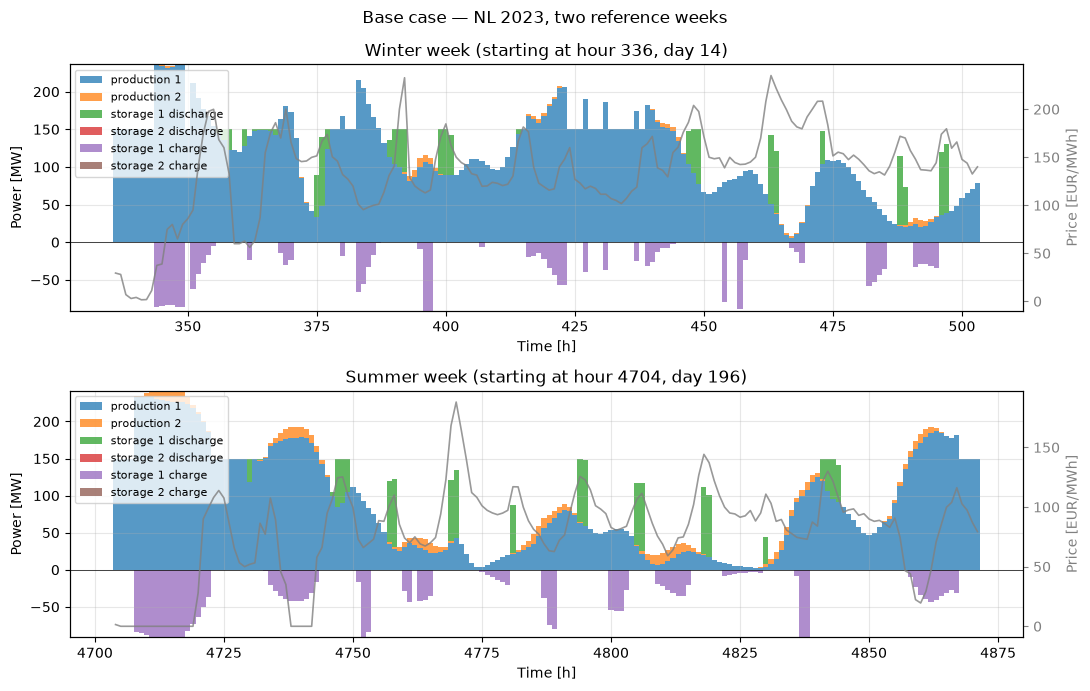

In [41]:
def plot_schedule_two_weeks(os_, price, week_winter_start, week_summer_start,
                            title=""):
    """Plot stacked generation + storage bars over two reference weeks,
    with price on the twin axis.

    week_winter_start, week_summer_start: hour indices into the timeseries,
    each the start of a 168-hour window. If None, they're chosen
    automatically (min and max mean daily temperature proxy = mean price).
    """
    dt = os_.power_out.dt
    n = len(os_.power_out.data)

    # Default reference weeks: mid-January (winter) and mid-July (summer),
    # as fixed day offsets from the start of the timeseries. 24 h/day.
    WINTER_DEFAULT_DAY = 14   # 14 January
    SUMMER_DEFAULT_DAY = 196  # 15 July
    if week_winter_start is None:
        week_winter_start = WINTER_DEFAULT_DAY * 24
    if week_summer_start is None:
        week_summer_start = SUMMER_DEFAULT_DAY * 24

    # Guard against windows that run past the end of the timeseries.
    assert week_winter_start + 24 * 7 <= n, (
        f"Winter week starting at hour {week_winter_start} extends past "
        f"the end of the timeseries (n = {n})."
    )
    assert week_summer_start + 24 * 7 <= n, (
        f"Summer week starting at hour {week_summer_start} extends past "
        f"the end of the timeseries (n = {n})."
    )

    windows = [
        ("Winter week", week_winter_start),
        ("Summer week", week_summer_start),
    ]

    prod = [p.data[:n] for p in os_.production_p]
    stor = [s.data[:n] for s in os_.storage_p]
    price_arr = np.asarray(price)

    fig, axes = plt.subplots(2, 1, figsize=(11, 7))
    for ax, (label, start) in zip(axes, windows):
        end = start + 24 * 7
        t = np.arange(start, end) * dt
        window_slice = slice(start, end)

        # Positive stacking
        bottom_pos = np.zeros(end - start)
        for i, p in enumerate(prod):
            vals = p[window_slice]
            ax.bar(t, vals, width=dt, bottom=bottom_pos,
                   label=f"production {i+1}", alpha=0.75)
            bottom_pos = bottom_pos + vals
        for i, s in enumerate(stor):
            pos = np.maximum(s[window_slice], 0)
            ax.bar(t, pos, width=dt, bottom=bottom_pos,
                   label=f"storage {i+1} discharge", alpha=0.75)
            bottom_pos = bottom_pos + pos

        # Negative stacking
        bottom_neg = np.zeros(end - start)
        for i, s in enumerate(stor):
            neg = np.minimum(s[window_slice], 0)
            ax.bar(t, neg, width=dt, bottom=bottom_neg,
                   label=f"storage {i+1} charge", alpha=0.75)
            bottom_neg = bottom_neg + neg

        ax.axhline(0, color="k", lw=0.5)
        ax.set_xlabel("Time [h]")
        ax.set_ylabel("Power [MW]")
        ax.set_title(f"{label} (starting at hour {start}, day {start//24})")
        ax.legend(loc="upper left", fontsize=8)
        ax.grid(alpha=0.3)

        ax2 = ax.twinx()
        ax2.plot(t, price_arr[window_slice], color="grey", lw=1.2,
                 alpha=0.8, label="price")
        ax2.set_ylabel("Price [EUR/MWh]", color="grey")
        ax2.tick_params(axis="y", colors="grey")

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

plot_schedule_two_weeks(os_result, price_ts.data,
                        week_winter_start=None, week_summer_start=None,
                        title="Base case — NL 2023, two reference weeks")

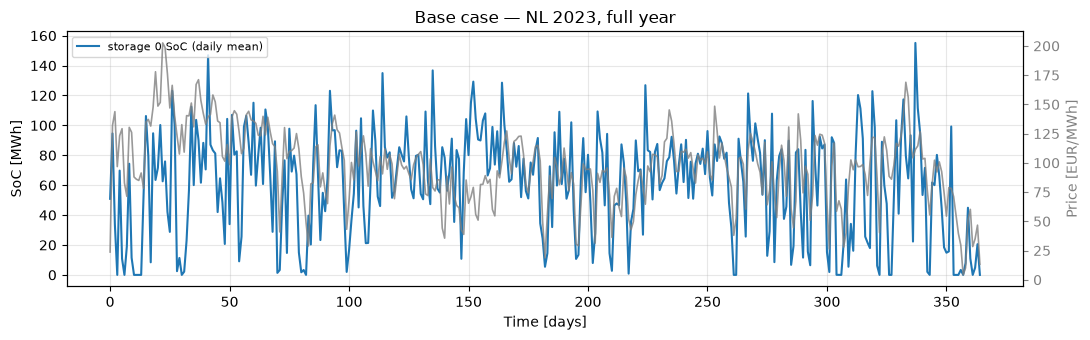

In [42]:
def plot_soc(os_, price, title=""):
    """Plot storage state-of-charge with price on the twin axis.

    When n > AGGREGATE_THRESHOLD, both series are averaged to daily resolution.
    Mean SoC is meaningful; max SoC per day would lose the intra-day shape.
    """
    dt = os_.storage_e[0].dt
    n = len(os_.storage_e[0].data)
    t = np.arange(n) * dt

    price_arr = np.asarray(price)

    t_price_agg, price_agg, _, is_daily = _aggregate(
        t, price_arr[:n], dt, mode='mean')

    fig, ax = plt.subplots(figsize=(11, 3.5))

    for i, e in enumerate(os_.storage_e):
        if np.any(e.data):
            t_agg, soc_agg, dt_agg, _ = _aggregate(t, e.data, dt, mode='mean')
            ax.plot(t_agg, soc_agg, label=f"storage {i} SoC"
                    + (" (daily mean)" if is_daily else ""))

    ax.set_xlabel("Time [days]" if is_daily else "Time [h]")
    ax.set_ylabel("SoC [MWh]")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(alpha=0.3)

    ax2 = ax.twinx()
    ax2.plot(t_price_agg, price_agg, color="grey",
             lw=1.2, alpha=0.8, label="price")
    ax2.set_ylabel("Price [EUR/MWh]", color="grey")
    ax2.tick_params(axis="y", colors="grey")

    fig.tight_layout()
    plt.show()

plot_soc(os_result, price_ts.data,
         title="Base case — NL 2023, full year")